# LISA galactic binary: Fourier and WDM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/avivajpeyi/lisa_gb_wdm_analysis_demo/blob/main/gb_demo.ipynb)

Run all in a Python ≥3.12 CPU runtime. Simulate one year of A/E data and fit $f_0$, $\dot f$, and $A$, with and without gaps. Sky, orientation, and instrument noise are fixed.

## 1. Setup

In [1]:
!pip install -q jaxgb==0.2.1 lisaorbits==3.1.0 lisaanalysistools==1.2.8 \
    "wdm-transform[jax]==0.5.0" emcee==3.1.6 gpubackendtools==0.1.1 \
    astropy==7.2.0 matplotlib

In [2]:
import os
import sys
import platform
from importlib.metadata import version
from time import perf_counter

assert sys.version_info >= (3, 12), "Use a Python 3.12+ runtime."
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.linalg import eigh
from scipy.optimize import minimize
from scipy.signal import hilbert
import emcee
from jaxgb.jaxgb import JaxGB
from lisaorbits import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A2TDISens
from wdm_transform import WDM, TimeSeries
from wdm_transform.transforms import (
    from_freq_to_wdm_band, from_wdm_to_freq_subband,
    fourier_span_from_wdm_span, wdm_span_from_fourier_span,
)

plt.rcParams.update({"font.size": 11, "figure.figsize": (11, 3.5)})
BLUE, ORANGE, OLIVE = "#2463a6", "#c46b27", "#628342"
packages = ["jaxgb", "lisaorbits", "lisaanalysistools", "wdm-transform", "emcee", "jax", "numpy", "scipy", "gpubackendtools", "astropy"]
print("Python", sys.version.split()[0], "| JAX devices:", jax.devices())

Python 3.12.12 | JAX devices: [CpuDevice(id=0)]


## 2. Source and settings

In [3]:
T = 365.25 * 86400
N, NT, NSLOW = 2**18, 64, 1024
DT, DAY = T / N, 86400
F0, FDOT, A0 = 3e-3, 1e-15, 3.6448032791850685e-23
GAPS = [(60, 67), (150, 157), (240, 247)]
TAPER_DAYS, GUARD_ROWS = 2., 3
SEED = 20261002
response = JaxGB(EqualArmlengthOrbits(), t_obs=T, t0=0, n=NSLOW)

@jax.jit
def binary(theta):
    # theta = [T * delta_f0, T**2 * delta_fdot, A / A0]
    parameters = jnp.array([F0 + theta[0] / T, FDOT + theta[1] / T**2,
                            A0 * theta[2], 1., .4, .3, .8, .2])
    a, e, _ = response.get_tdi(parameters, tdi_generation=2, tdi_combination="AET")
    return jnp.stack([a, e]), response.get_kmin(parameters[0])

time = np.arange(N) * DT
frequency = np.fft.rfftfreq(N, DT)
psd = get_sensitivity(np.maximum(frequency, frequency[1]),
                      sens_fn=A2TDISens, model="scirdv1")
injection = np.array([0., 0., 1.])
h, first = binary(injection)
source_bins = np.arange(int(first) - 3, int(first) + NSLOW + 3)
columns = np.arange(round(F0 * 2 * T / NT) - 2, round(F0 * 2 * T / NT) + 3)
print(f"One year | f0 = {F0 * 1e3:g} mHz | fdot = {FDOT:g} Hz/s | A = {A0:.6g}")

One year | f0 = 3 mHz | fdot = 1e-15 Hz/s | A = 3.6448e-23


## 3. Simulate A/E

In [4]:
rng = np.random.default_rng(SEED)
spectrum = np.zeros((2, len(frequency)), complex)
spectrum[:, int(first):int(first) + NSLOW] = np.asarray(h) / DT
signal = np.fft.irfft(spectrum, n=N, axis=1)
noise = np.sqrt(N * psd / (4 * DT)) * (
    rng.normal(size=spectrum.shape) + 1j * rng.normal(size=spectrum.shape))
for k in [0, -1]:
    noise[:, k] = rng.normal(size=2) * np.sqrt(N * psd[k] / (2 * DT))
data = signal + np.fft.irfft(noise, n=N, axis=1)
available = np.ones(N, bool)
for start, stop in GAPS:
    available &= ~((time >= start * DAY) & (time < stop * DAY))
gapped_data = np.where(available, data, np.nan)
del spectrum, noise

## 4. Taper the ends and gaps

Two-day cosine ramps on the available side of each boundary; apply the same windows to data and templates.

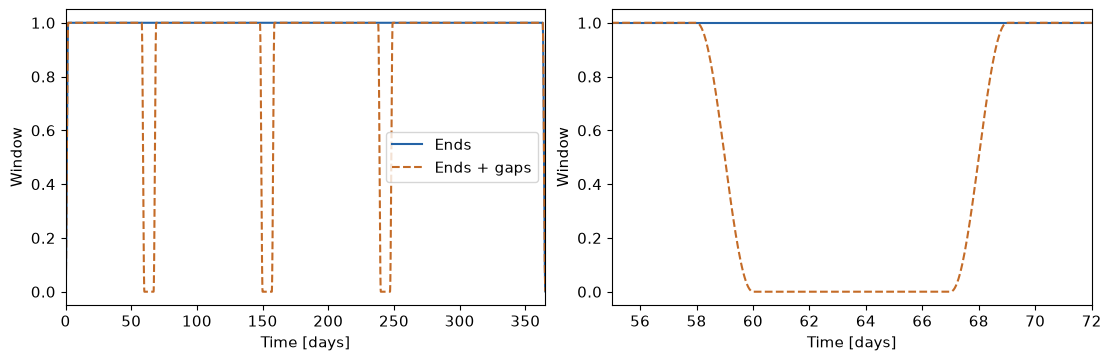

WDM rows kept: 64 continuous; 30 gapped


In [5]:
def cosine_ramp(distance):
    return .5 * (1 - np.cos(np.pi * np.clip(distance / (TAPER_DAYS * DAY), 0, 1)))

end_window = cosine_ramp(time) * cosine_ramp(time[-1] - time)
gap_window = end_window.copy()
for start, stop in GAPS:
    # Ramp down before the gap and up after it; zero throughout the gap.
    distance = np.maximum(start * DAY - time, time - stop * DAY)
    gap_window *= cosine_ramp(distance)
assert end_window[0] == end_window[-1] == 0
assert np.all(gap_window[~available] == 0)

row_spacing = T / NT
row_time = np.arange(NT) * row_spacing
half_cell = row_spacing / 2
margin = TAPER_DAYS * DAY + GUARD_ROWS * row_spacing
keep_continuous = np.ones(NT, bool)  # retain every row for the equivalent continuous fit
keep_gapped = (row_time - half_cell > margin) & (row_time + half_cell < T - margin)
for start, stop in GAPS:
    keep_gapped &= ~((row_time + half_cell >= start * DAY - margin)
                     & (row_time - half_cell <= stop * DAY + margin))

fig, axes = plt.subplots(1, 2, layout="constrained")
for axis, limits in zip(axes, [(0, 365.25), (55, 72)]):
    axis.plot(time[::32] / DAY, end_window[::32], color=BLUE, label="Ends")
    axis.plot(time[::32] / DAY, gap_window[::32], color=ORANGE, ls="--", label="Ends + gaps")
    axis.set(xlim=limits, ylim=(-.05, 1.05), xlabel="Time [days]", ylabel="Window")
axes[0].legend()
plt.show()
print("WDM rows kept:", keep_continuous.sum(), "continuous;", keep_gapped.sum(), "gapped")

## 5. Signal with and without gaps

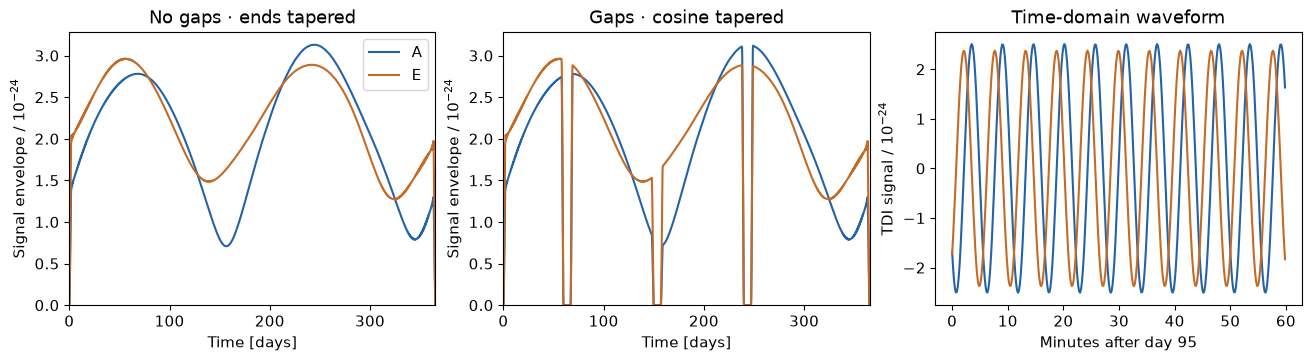

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), layout="constrained")
for channel, color, label in [(0, BLUE, "A"), (1, ORANGE, "E")]:
    envelope = abs(hilbert(signal[channel]))
    for axis, window in zip(axes[:2], [end_window, gap_window]):
        axis.plot(time[::128] / DAY, (envelope * window)[::128] / 1e-24,
                  color=color, label=label)
    dense_time = 95 * DAY + np.arange(0, 3600, 10.)
    source_frequency = (int(first) + np.arange(NSLOW)) / T
    dense = 2 / T * np.real(np.asarray(h[channel]) @ np.exp(
        2j * np.pi * source_frequency[:, None] * dense_time[None, :]))
    axes[2].plot((dense_time - 95 * DAY) / 60, dense / 1e-24, color=color, label=label)
for axis, title in zip(axes[:2], ["No gaps · ends tapered", "Gaps · cosine tapered"]):
    axis.set(xlabel="Time [days]", ylabel=r"Signal envelope / $10^{-24}$",
             title=title, xlim=(0, 365.25), ylim=(0, 1.05 * abs(hilbert(signal)).max() / 1e-24))
axes[2].set(xlabel="Minutes after day 95", ylabel=r"TDI signal / $10^{-24}$",
            title="Time-domain waveform")
axes[0].legend()
plt.show()


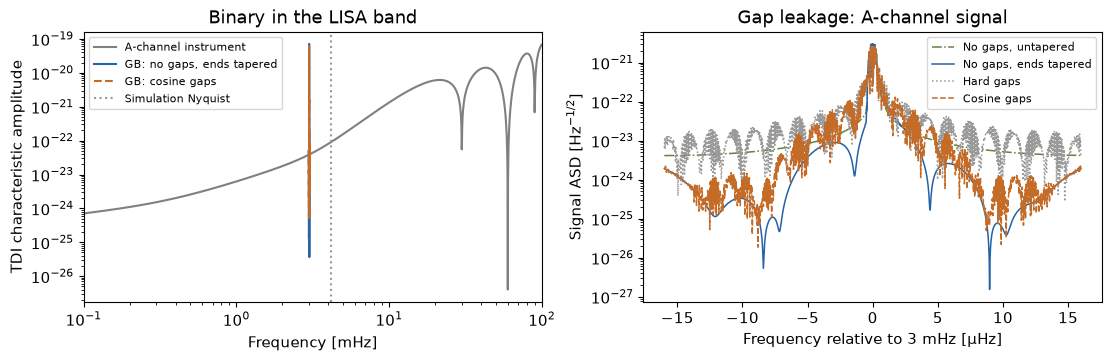

In [7]:
signal_fft = DT * np.fft.rfft(signal, axis=1)
end_fft = DT * np.fft.rfft(signal * end_window, axis=1)
hard_gap_fft = DT * np.fft.rfft(signal * available * end_window, axis=1)
gap_fft = DT * np.fft.rfft(signal * gap_window, axis=1)
fig, axes = plt.subplots(1, 2, layout="constrained")
context = np.geomspace(1e-4, .1, 2000)
context_psd = get_sensitivity(context, sens_fn=A2TDISens, model="scirdv1")
axes[0].loglog(context * 1e3, np.sqrt(context * context_psd), color=".5", label="A-channel instrument")
near = abs(frequency - F0) < 16e-6
axes[0].loglog(frequency[near] * 1e3, 2 * frequency[near] * abs(end_fft[0, near]),
               color=BLUE, label="GB: no gaps, ends tapered")
axes[0].loglog(frequency[near] * 1e3, 2 * frequency[near] * abs(gap_fft[0, near]),
               color=ORANGE, ls="--", label="GB: cosine gaps")
axes[0].axvline(frequency[-1] * 1e3, color=".6", ls=":", label="Simulation Nyquist")
axes[0].set(xlim=(.1, 100), xlabel="Frequency [mHz]", ylabel="TDI characteristic amplitude",
            title="Binary in the LISA band")
for values, label, color, style in [(signal_fft, "No gaps, untapered", OLIVE, "-."),
                                   (end_fft, "No gaps, ends tapered", BLUE, "-"),
                                   (hard_gap_fft, "Hard gaps", "0.6", ":"),
                                   (gap_fft, "Cosine gaps", ORANGE, "--")]:
    axes[1].semilogy((frequency[near] - F0) * 1e6, np.sqrt(2 / T) * abs(values[0, near]),
                     color=color, ls=style, lw=1.1, label=label)
axes[1].set(xlabel="Frequency relative to 3 mHz [µHz]", ylabel=r"Signal ASD [Hz$^{-1/2}$]",
            title="Gap leakage: A-channel signal")
for axis in axes: axis.legend(fontsize=8)
plt.show()

## 6. WDM in a frequency band

Use `wdm_transform.transforms.from_freq_to_wdm_band` for the requested channels, including their full Fourier support. A time window still needs an FFT; only the WDM stage is restricted to this band.

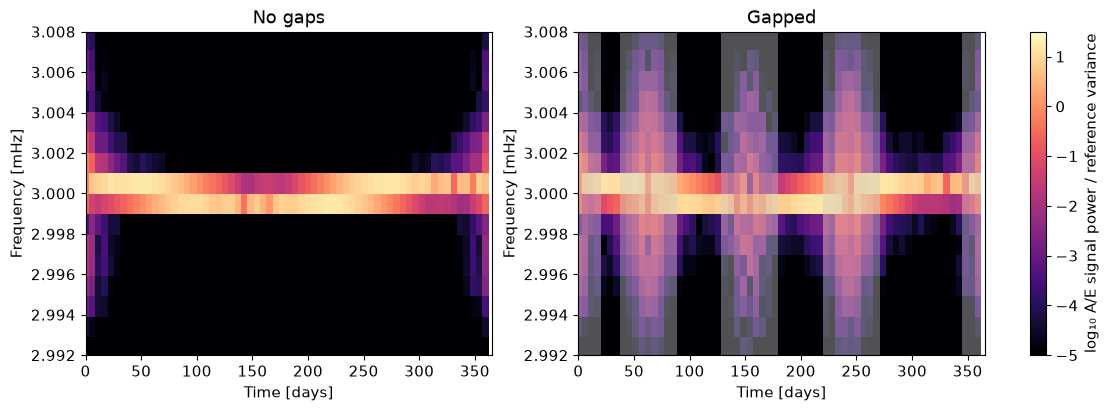

Band transform matches the full WDM transform; shaded rows are excluded from the gapped fit.


In [8]:
WDM_GRID = dict(nfreqs_fourier=len(frequency), nfreqs_wdm=N // NT, ntimes_wdm=NT)
grid_frequency = np.arange(N // NT + 1) * NT / (2 * T)
reference_sd = np.sqrt(N * psd[round(F0 * T)] / (2 * DT))

def transform_band(spectra, kmin, selected_columns):
    # Package API accepts one spectrum; vmap applies it to A/E or basis batches.
    return jax.vmap(lambda spectrum: from_freq_to_wdm_band(
        spectrum, df=1 / T, kmin=int(kmin), **WDM_GRID,
        mmin=int(selected_columns[0]), nf_sub_wdm=len(selected_columns), backend="jax",
    ))(jnp.asarray(spectra))

def wdm_band(samples, selected_columns):
    kmin, length = fourier_span_from_wdm_span(
        **WDM_GRID, mmin=int(selected_columns[0]), nf_sub_wdm=len(selected_columns))
    spectra = np.fft.rfft(samples, axis=-1)[:, kmin:kmin + length]
    return np.asarray(transform_band(spectra, kmin, selected_columns))

plot_columns = np.flatnonzero(abs(grid_frequency - F0) < 8e-6)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for axis, window, keep, label in zip(axes, [end_window, gap_window],
                                    [keep_continuous, keep_gapped], ["No gaps", "Gapped"]):
    coefficients = wdm_band(signal * window, plot_columns)
    power = np.sum(coefficients**2, axis=0) / reference_sd**2
    image = axis.pcolormesh(row_time / DAY, grid_frequency[plot_columns] * 1e3,
                           np.log10(np.maximum(power.T, 1e-8)),
                           cmap="magma", vmin=-5, vmax=1.5, shading="nearest")
    for center in row_time[~keep]:
        axis.axvspan((center - half_cell) / DAY, (center + half_cell) / DAY,
                     color=".8", alpha=.4, linewidth=0)
    axis.set(title=label, xlim=(0, 365.25), xlabel="Time [days]",
             ylabel="Frequency [mHz]", ylim=(2.992, 3.008))
fig.colorbar(image, ax=axes.tolist(), label="log₁₀ A/E signal power / reference variance")
plt.show()

# Check the compact API against the full package transform once.
full = WDM.from_time_series(TimeSeries(signal * gap_window, dt=DT), nt=NT, backend="jax")
np.testing.assert_allclose(wdm_band(signal * gap_window, plot_columns),
                           np.asarray(full.coeffs)[:, :, plot_columns], atol=1e-30)
del full
print("Band transform matches the full WDM transform; shaded rows are excluded from the gapped fit.")

## 7. Likelihoods

For the continuous comparison, transform the same tapered Fourier band into WDM and carry its full covariance. Precompute the linear template projection for fast calls; no new transform runs inside each likelihood. Gapped WDM keeps guarded rows and checks its diagonal covariance approximation.

In [9]:
def wdm_atoms(columns):
    # Package inverse of unit coefficients gives the analysis basis / N.
    atoms = np.empty((NT * len(columns), N))
    for start in range(0, len(atoms), 8):
        index = np.arange(start, min(start + 8, len(atoms)))
        coefficients = np.zeros((len(index), NT, len(columns)))
        coefficients[np.arange(len(index)), index // len(columns),
                     index % len(columns)] = 1
        compact = jax.vmap(lambda c: from_wdm_to_freq_subband(
            c, df=1 / T, **WDM_GRID, mmin=int(columns[0]), backend="jax")[0]
        )(jnp.asarray(coefficients))
        kmin, length = fourier_span_from_wdm_span(
            **WDM_GRID, mmin=int(columns[0]), nf_sub_wdm=len(columns))
        spectrum = np.zeros((len(index), len(frequency)), complex)
        spectrum[:, kmin:kmin + length] = np.asarray(compact)
        atoms[index] = np.fft.irfft(spectrum, n=N, axis=1) * N / reference_sd
    return atoms

def prepare(atoms, window):
    # Apply the identical window to observations, templates, and noise covariance.
    atoms = atoms * window
    observed, injected = data @ atoms.T, signal @ atoms.T
    atom_fft = np.fft.rfft(atoms, axis=1)
    del atoms
    projection = (2 / N / DT) * atom_fft[:, source_bins].conj()
    atom_fft *= np.sqrt(psd / (N * DT))
    atom_fft[:, [0, -1]] /= np.sqrt(2)
    covariance = np.real(atom_fft @ atom_fft.conj().T)
    return observed, injected, projection, covariance


def make_likelihood(observed, injected, projection, covariance, diagonal=False):
    variance = covariance.diagonal()
    correlation = covariance / np.sqrt(variance[:, None] * variance[None, :])
    if diagonal:
        discrepancy = np.max(abs(eigh(correlation - np.eye(len(variance)), eigvals_only=True)))
        assert discrepancy < .01, f"Add guard rows: covariance discrepancy = {discrepancy:.3g}"
        white_data = observed / np.sqrt(variance)
        white_signal = injected / np.sqrt(variance)
        white_projection = projection / np.sqrt(variance[:, None])
        rank = len(variance)
    else:
        eigenvalues, vectors = eigh(covariance)
        retained = eigenvalues > eigenvalues[-1] * 1e-10
        whitening = (vectors[:, retained] / np.sqrt(eigenvalues[retained])).T
        white_data = observed @ whitening.T
        white_signal = injected @ whitening.T
        white_projection = whitening @ projection
        rank, discrepancy = int(retained.sum()), None
    projection_jax, observed_jax = jnp.asarray(white_projection), jnp.asarray(white_data)

    @jax.jit
    def model(theta):
        h, first = binary(theta)
        index = jnp.arange(NSLOW) + first - source_bins[0]
        return jnp.real(h @ projection_jax[:, index].T)

    @jax.jit
    def likelihood(theta):
        return -.5 * jnp.sum((observed_jax - model(theta))**2)

    np.testing.assert_allclose(model(injection), white_signal, atol=1e-9)
    noise_energy = float(np.sum((white_data - white_signal)**2))
    assert abs(noise_energy - 2 * rank) < 5 * np.sqrt(4 * rank)
    return likelihood, dict(snr=float(np.linalg.norm(white_signal)),
                            covariance_discrepancy=None if discrepancy is None else float(discrepancy),
                            kept_modes=rank, total_modes=len(variance),
                            noise_energy=noise_energy)

In [10]:
setup_started = perf_counter()
likelihoods, checks = {}, {}
# Continuous Fourier: tapered data in a declared band, with exact covariance.
fft_bins = np.flatnonzero(abs(frequency - F0) < 3e-6)
reference_fft = np.sqrt(T * psd[round(F0 * T)] / 4)
phase = 2 * np.pi * fft_bins[:, None] * np.arange(N)[None, :] / N
atoms = np.concatenate([np.cos(phase), -np.sin(phase)]) * DT / reference_fft
fft_observed, fft_signal, fft_projection, fft_covariance = prepare(atoms, end_window)
del phase, atoms
likelihoods["Fourier continuous"], checks["Fourier continuous"] = make_likelihood(
    fft_observed, fft_signal, fft_projection, fft_covariance)
direct = DT * np.fft.rfft(data * end_window, axis=1)[:, fft_bins] / reference_fft
np.testing.assert_allclose(fft_observed, np.concatenate([direct.real, direct.imag], axis=1), atol=2e-7)

# Transform unit Fourier coordinates in the same band using the package API.
mmin, nf_sub = wdm_span_from_fourier_span(
    **WDM_GRID, kmin=int(fft_bins[0]), lendata=len(fft_bins))
continuous_columns = np.arange(mmin, mmin + nf_sub)
mode_count = 2 * len(fft_bins)
rotation = np.empty((NT * len(continuous_columns), mode_count))
for start in range(0, mode_count, 8):
    index = np.arange(start, min(start + 8, mode_count))
    unit_spectrum = np.zeros((len(index), len(fft_bins)), complex)
    unit_spectrum[np.arange(len(index)), index % len(fft_bins)] = (
        np.where(index < len(fft_bins), 1., 1j) * reference_fft / DT)
    coefficients = np.asarray(transform_band(unit_spectrum, fft_bins[0], continuous_columns))
    rotation[:, index] = coefficients.reshape(len(index), -1).T / reference_sd
# Losing any Fourier mode here would invalidate posterior equivalence.
np.testing.assert_allclose(rotation.T @ rotation, np.eye(mode_count), atol=1e-10)

wdm_observed = fft_observed @ rotation.T
likelihoods["WDM continuous"], checks["WDM continuous"] = make_likelihood(
    wdm_observed, fft_signal @ rotation.T,
    rotation @ fft_projection, rotation @ fft_covariance @ rotation.T)
assert checks["WDM continuous"]["kept_modes"] == checks["Fourier continuous"]["kept_modes"]
# Direct package transform of the band-limited observation.
band_spectrum = (fft_observed[:, :len(fft_bins)] +
                 1j * fft_observed[:, len(fft_bins):]) * reference_fft / DT
direct = np.asarray(transform_band(band_spectrum, fft_bins[0], continuous_columns))
np.testing.assert_allclose(wdm_observed, direct.reshape(2, -1) / reference_sd, atol=1e-8)

# Gapped WDM: raw time gaps + cosine tapers + guarded row selection.
atoms = wdm_atoms(columns)[np.repeat(keep_gapped, len(columns))]
gap_observed, gap_signal, gap_projection, gap_covariance = prepare(atoms, gap_window)
likelihoods["WDM gapped"], checks["WDM gapped"] = make_likelihood(
    gap_observed, gap_signal, gap_projection, gap_covariance, diagonal=True)
direct = wdm_band(data * gap_window, columns)[:, keep_gapped].reshape(2, -1) / reference_sd
np.testing.assert_allclose(gap_observed, direct, atol=1e-8)
del atoms, unit_spectrum, coefficients, band_spectrum, direct

# Verify likelihood SHAPE across the prior before running any sampler.
rng_check = np.random.default_rng(42)
points = np.column_stack([rng_check.uniform(-.95, .95, 30),
                          rng_check.uniform(-2.9, 2.9, 30),
                          rng_check.uniform(.31, 1.99, 30)])
fft_ll, wdm_ll = likelihoods["Fourier continuous"], likelihoods["WDM continuous"]
parity_error = max(abs(float(fft_ll(p) - fft_ll(injection)) -
                       float(wdm_ll(p) - wdm_ll(injection))) for p in points)
assert parity_error < 1e-7
print(f"Continuous likelihood parity: max |delta log L difference| = {parity_error:.2g}")
for name, result in checks.items():
    weighting = ("full covariance" if result["covariance_discrepancy"] is None else
                 f"diagonal approximation error {100 * result['covariance_discrepancy']:.3f}%")
    print(f"{name}: SNR {result['snr']:.2f}; modes {result['kept_modes']}; {weighting}")

setup_seconds = perf_counter() - setup_started

Continuous likelihood parity: max |delta log L difference| = 6.8e-13
Fourier continuous: SNR 24.97; modes 378; full covariance
WDM continuous: SNR 24.97; modes 378; full covariance
WDM gapped: SNR 16.47; modes 150; diagonal approximation error 0.411%


## 8. Likelihood runtime

Median and interquartile range over seven repeats, after JIT warm-up and with JAX synchronization. Calls include JaXGB templates and the precomputed projection; setup is separate. The 24-point batch matches the ensemble size; emcee also uses 12-point half-ensembles.

In [11]:
def benchmark_likelihood(log_likelihood, batch_size=1, repeats=7, calls=128):
    evaluate = log_likelihood if batch_size == 1 else jax.jit(jax.vmap(log_likelihood))
    rng = np.random.default_rng(123)
    points = injection + rng.normal(size=(calls, batch_size, 3)) * [0.05, 0.1, 0.02]
    arguments = jnp.asarray(points[:, 0] if batch_size == 1 else points)
    inputs = [arguments[i] for i in range(calls)]  # transfer/indexing outside the timer
    for x in inputs[:3]:
        evaluate(x).block_until_ready()
    timings = []
    for _ in range(repeats):
        started = perf_counter()
        for x in inputs:
            evaluate(x).block_until_ready()
        timings.append((perf_counter() - started) * 1e3 / calls)
    return np.quantile(timings, [.25, .5, .75])

likelihood_timings = {}
rows = ["| Fit | Single call [ms], median (IQR) | 24-point batch [ms], median (IQR) |",
        "|:--|--:|--:|"]
for name, likelihood in likelihoods.items():
    single = benchmark_likelihood(likelihood)
    batch = benchmark_likelihood(likelihood, batch_size=24)
    likelihood_timings[name] = dict(single_ms=single.tolist(), batch_ms=batch.tolist())
    rows.append(f"| {name} | {single[1]:.3f} ({single[0]:.3f}–{single[2]:.3f}) | "
                f"{batch[1]:.3f} ({batch[0]:.3f}–{batch[2]:.3f}) |")
display(Markdown("\n".join(rows)))
print(f"Likelihood setup (basis, projections, covariance, parity checks): {setup_seconds:.1f} s")
print("Timing host:", platform.platform(), "|", platform.machine(), "|", jax.devices())

| Fit | Single call [ms], median (IQR) | 24-point batch [ms], median (IQR) |
|:--|--:|--:|
| Fourier continuous | 0.351 (0.345–0.388) | 5.424 (5.320–5.532) |
| WDM continuous | 0.320 (0.318–0.322) | 5.241 (5.099–5.514) |
| WDM gapped | 0.234 (0.231–0.246) | 2.811 (2.693–2.904) |

Likelihood setup (basis, projections, covariance, parity checks): 4.0 s
Timing host: macOS-26.5.1-arm64-arm-64bit | arm64 | [CpuDevice(id=0)]


## 9. Fit $f_0$, $\dot f$, $A$

Uniform priors: $T\Delta f_0\in[-1,1]$, $T^2\Delta\dot f\in[-3,3]$, $A/A_0\in[0.3,2]$. Two independent emcee ensembles per fit.

In [12]:
def sample(log_likelihood, seed):
    total_started = perf_counter()
    @jax.jit
    def log_posterior(theta):
        inside = ((jnp.abs(theta[0]) < 1) & (jnp.abs(theta[1]) < 3)
                  & (theta[2] > 0.3) & (theta[2] < 2))
        return jnp.where(inside, log_likelihood(theta), -jnp.inf)

    batch = jax.jit(jax.vmap(log_posterior))
    setup_started = perf_counter()
    log_posterior(jnp.asarray(injection)).block_until_ready()
    for size in [12, 24]:
        batch(jnp.tile(jnp.asarray(injection), (size, 1))).block_until_ready()
    fit = minimize(lambda x: -float(log_posterior(x)), [0.03, -0.15, 1],
                   method="Nelder-Mead", options={"xatol": 1e-7, "maxiter": 1500})
    assert fit.success
    setup_time = perf_counter() - setup_started
    rng = np.random.default_rng(seed)
    chains, diagnostics = [], []
    for run in range(2):
        evaluations = 0
        def evaluate_batch(x):
            nonlocal evaluations
            evaluations += len(x)
            return np.asarray(batch(x))  # synchronizes JAX before emcee proceeds
        sampler = emcee.EnsembleSampler(24, 3, evaluate_batch, vectorize=True)
        sampler.random_state = np.random.RandomState(seed + run).get_state()
        start = fit.x + rng.normal(size=(24, 3)) * [0.04, 0.12, 0.04]
        burn_started = perf_counter()
        state = sampler.run_mcmc(start, 700)
        burn_seconds = perf_counter() - burn_started
        sampler.reset()
        production_started = perf_counter()
        sampler.run_mcmc(state, 3500)
        while sampler.iteration < 7500:
            tau = sampler.get_autocorr_time(tol=0)
            if sampler.iteration > 70 * tau.max():
                break
            sampler.run_mcmc(None, 1000)
        production_seconds = perf_counter() - production_started
        chain = sampler.get_chain()
        tau = sampler.get_autocorr_time(tol=0)
        assert sampler.iteration > 50 * tau.max()
        chains.append(chain)
        diagnostics.append(dict(steps=sampler.iteration, tau=tau.tolist(),
                                burn_seconds=burn_seconds, production_seconds=production_seconds,
                                posterior_evaluations=evaluations,
                                acceptance=float(sampler.acceptance_fraction.mean())))
    samples = np.concatenate([c.reshape(-1, 3) for c in chains])
    difference = np.abs(chains[0].mean((0, 1)) - chains[1].mean((0, 1))) / samples.std(0)
    assert np.max(difference) < 0.15
    return samples, chains, dict(map=fit.x.tolist(), ensembles=diagnostics,
                                 setup_seconds=setup_time, wall_seconds=perf_counter() - total_started,
                                 ensemble_mean_difference_over_sd=difference.tolist(),
                                 quantiles=np.quantile(samples, [0.05, 0.5, 0.95], axis=0).tolist(),
                                 sd=samples.std(0).tolist())

In [13]:
samples, diagnostics = {}, {}
for i, (name, likelihood) in enumerate(likelihoods.items()):
    print("Fitting", name, flush=True)
    samples[name], chains, diagnostics[name] = sample(likelihood, SEED + 100 * i)
    del chains
    print("  done; max independent-ensemble mean difference / SD:",
          round(max(diagnostics[name]["ensemble_mean_difference_over_sd"]), 3), flush=True)

Fitting Fourier continuous


  done; max independent-ensemble mean difference / SD: 0.015


Fitting WDM continuous


  done; max independent-ensemble mean difference / SD: 0.021


Fitting WDM gapped


  done; max independent-ensemble mean difference / SD: 0.054


## 10. Posteriors and checks

Fourier continuous | injection in 90% intervals: [ True  True  True]
WDM continuous | injection in 90% intervals: [ True  True  True]
WDM gapped | injection in 90% intervals: [ True  True  True]


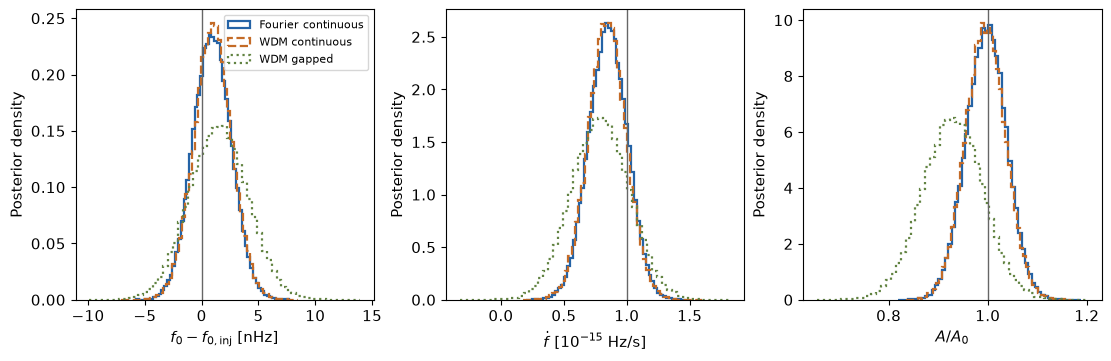

Fourier continuous | production / autocorrelation time: [83.7 97.8]
WDM continuous | production / autocorrelation time: [90.7 92.8]
WDM gapped | production / autocorrelation time: [89.9 97.3]
Gapped / continuous WDM posterior SD: [1.53 1.5  1.5 ]
Packages: {'jaxgb': '0.2.1', 'lisaorbits': '3.1.0', 'lisaanalysistools': '1.2.8', 'wdm-transform': '0.5.0', 'emcee': '3.1.6', 'jax': '0.11.2', 'numpy': '2.5.3', 'scipy': '1.18.1', 'gpubackendtools': '0.1.1', 'astropy': '7.2.0'}
Continuous mean difference / SD: [0.045 0.04  0.033]
Continuous WDM / Fourier posterior SD: [0.998 0.997 0.996]


In [14]:
fig, axes = plt.subplots(1, 3, layout="constrained")
for (name, values), color, style in zip(samples.items(), [BLUE, ORANGE, OLIVE], ["-", "--", ":"]):
    physical = np.column_stack([values[:, 0] / T * 1e9,
                               (FDOT + values[:, 1] / T**2) * 1e15, values[:, 2]])
    for i, axis in enumerate(axes):
        axis.hist(physical[:, i], bins=55, density=True, histtype="step",
                  color=color, ls=style, lw=1.6, label=name)
    lo, median, hi = np.quantile(values, [.05, .5, .95], axis=0)
    print(name, "| injection in 90% intervals:", (lo < injection) & (injection < hi))
for axis, truth, label in zip(axes, [0, 1, 1],
    [r"$f_0-f_{0,\mathrm{inj}}$ [nHz]", r"$\dot f$ [$10^{-15}$ Hz/s]", r"$A/A_0$"]):
    axis.axvline(truth, color=".4", lw=1)
    axis.set(xlabel=label, ylabel="Posterior density")
axes[0].legend(fontsize=8)
plt.show()

for name, result in diagnostics.items():
    ratios = [run["steps"] / max(run["tau"]) for run in result["ensembles"]]
    assert min(ratios) > 50
    print(name, "| production / autocorrelation time:", np.round(ratios, 1))
print("Gapped / continuous WDM posterior SD:",
      np.round(samples["WDM gapped"].std(0) / samples["WDM continuous"].std(0), 2))
print("Packages:", {name: version(name) for name in packages})
mean_difference = abs(samples["Fourier continuous"].mean(0) -
                      samples["WDM continuous"].mean(0)) / samples["Fourier continuous"].std(0)
width_ratio = samples["WDM continuous"].std(0) / samples["Fourier continuous"].std(0)
assert max(mean_difference) < .1 and max(abs(width_ratio - 1)) < .03
print("Continuous mean difference / SD:", np.round(mean_difference, 3))
print("Continuous WDM / Fourier posterior SD:", np.round(width_ratio, 3))


## 11. MCMC runtime

Measured on this runtime: two ensembles × 24 walkers, 700 burn-in steps each. Production stops using autocorrelation checks, so compare the steps as well as the time. Total includes posterior JIT warm-up, optimization, sampling, and diagnostics.

| Fit | Setup + MAP [s] | Burn-in [s] | Production [s] | Production steps per ensemble | Posterior evaluations | Total [s] |
|:--|--:|--:|--:|:--|--:|--:|
| Fourier continuous | 0.52 | 9.12 | 42.03 | 3500, 3500 | 201,648 | 51.69 |
| WDM continuous | 0.47 | 8.59 | 43.71 | 3500, 3500 | 201,648 | 52.80 |
| WDM gapped | 0.46 | 4.96 | 25.91 | 3500, 3500 | 201,648 | 31.35 |

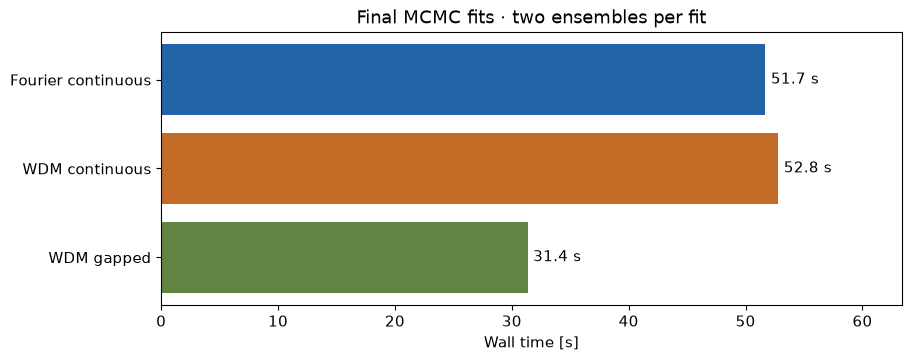

In [15]:
rows = ["| Fit | Setup + MAP [s] | Burn-in [s] | Production [s] | Production steps per ensemble | Posterior evaluations | Total [s] |",
        "|:--|--:|--:|--:|:--|--:|--:|"]
for name, result in diagnostics.items():
    runs = result["ensembles"]
    steps = ", ".join(str(run["steps"]) for run in runs)
    rows.append(f"| {name} | {result['setup_seconds']:.2f} | "
                f"{sum(run['burn_seconds'] for run in runs):.2f} | "
                f"{sum(run['production_seconds'] for run in runs):.2f} | {steps} | "
                f"{sum(run['posterior_evaluations'] for run in runs):,} | {result['wall_seconds']:.2f} |")
display(Markdown("\n".join(rows)))
fig, axis = plt.subplots(figsize=(9, 3.5), layout="constrained")
names = list(diagnostics)
values = [diagnostics[name]["wall_seconds"] for name in names]
axis.barh(names, values, color=[BLUE, ORANGE, OLIVE])
axis.bar_label(axis.containers[0], fmt="%.1f s", padding=4)
axis.set(xlabel="Wall time [s]", title="Final MCMC fits · two ensembles per fit",
         xlim=(0, 1.2 * max(values)))
axis.invert_yaxis()
plt.show()

One simulated realization and local sampling checks. Runtimes depend on the host; the gapped fit uses fewer modes. The broad instrument curve extends beyond the simulation Nyquist.

[JaXGB](https://pypi.org/project/jaxgb/0.2.1/) · [WDM band API](https://github.com/pywavelet/wdm_transform/blob/main/src/wdm_transform/transforms/__init__.py)